### H-series magnitude stats

In [4]:
import csv
import matplotlib.pyplot as plt
import numpy as np
import random
import os 
import pandas as pd
import matplotlib.pyplot as plt
import math
from __future__ import division
from scipy.stats import gaussian_kde
import star_chart_spherical_projection as scsp
import astropy.units as u
from astropy.time import Time
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, get_sun, Angle, Longitude
from sunpy.coordinates import frames, sun

# I want get_sun to shut up so ignoring warnings:
import warnings
warnings.simplefilter('ignore', UserWarning)

## H-series data

Text(0, 0.5, 'Frequency')

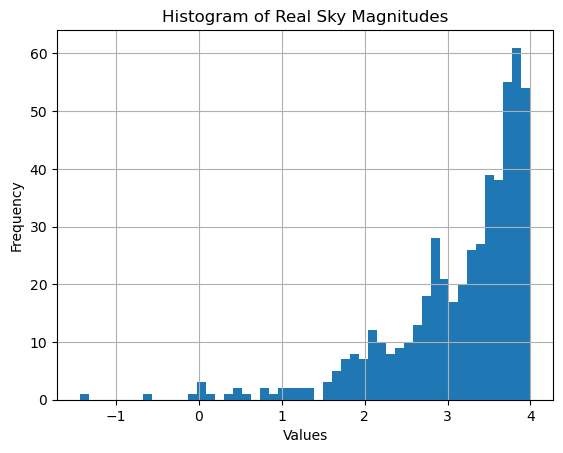

In [2]:
direct = os.getcwd()
name_df = pd.read_csv(direct + '/StarLists/RealSky/ICs/star_data_names.csv', index_col=None, header=0, names=['Name', 'RA', 'Dec', 'Mag'])

# Plot a histogram of a single column in the DataFrame
name_df.hist(column='Mag', bins=50)

# Set the title and axis labels
plt.title('Histogram of Real Sky Magnitudes')
plt.xlabel('Values')
plt.ylabel('Frequency')

In [2]:
#from __future__ import division
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.stats import gaussian_kde

# kde generator modified from https://stackoverflow.com/questions/17821458/random-number-from-histogram

def kde(x, x_grid, bandwidth=0.2, **kwargs):
    """Kernel Density Estimation with Scipy"""
    kde = gaussian_kde(x, bw_method=bandwidth / x.std(ddof=1), **kwargs)
    return kde.evaluate(x_grid)


def generate_rand_from_pdf(pdf, x_grid, num):
    cdf = np.cumsum(pdf)
    cdf = cdf / cdf[-1]
    values = np.random.rand(num)
    value_bins = np.searchsorted(cdf, values)
    random_from_cdf = x_grid[value_bins]
    return random_from_cdf
    

def generate_mags_from_Hdist(num):
    # get data 
    direct = os.getcwd()
    name_df = pd.read_csv(direct + '/StarLists/RealSky/ICs/star_data_names.csv', index_col=None, header=0, names=['Name', 'RA', 'Dec', 'Mag'])
    data = name_df['Mag'].values #np.random.normal(size=1000)
    # create kernel density estimator pdf
    x_grid = np.linspace(min(data), max(data), num)
    kdepdf = kde(data, x_grid, bandwidth=0.1)
    random_from_kde = generate_rand_from_pdf(kdepdf, x_grid, num)
    # return an array of num magnitudes
    return random_from_kde


test = generate_mags_from_Hdist(518)    

In [6]:
np.round(test, 2)

array([ 2.26,  3.71,  3.85,  3.88,  3.1 ,  3.95,  3.65,  3.85,  3.47,
        2.72,  1.75,  2.97,  3.69,  3.81,  3.05,  2.86,  3.63,  3.43,
        3.47,  3.53,  3.45,  0.02,  3.02,  3.84,  2.68,  3.86,  3.21,
        3.97,  2.59,  2.04,  3.26,  3.8 ,  2.26,  2.7 ,  2.92,  3.91,
        3.59,  3.75, -0.67,  2.32,  1.69,  0.89,  2.44,  3.18,  2.86,
        3.64,  2.14,  2.98,  3.85,  3.4 ,  3.13,  3.4 ,  3.71,  3.96,
        2.37,  2.78, -0.12,  3.04,  3.98,  1.67,  3.19,  1.92,  2.2 ,
        2.62,  2.99,  3.98,  1.25,  3.02,  3.96,  2.63,  3.14,  3.78,
        3.62,  2.91,  3.73,  2.97,  2.6 ,  3.49,  1.17,  2.84,  3.55,
        2.04,  2.57,  3.8 ,  2.93,  3.21,  3.3 ,  3.17,  3.27,  3.67,
        1.96,  3.69,  3.74,  2.58,  3.43,  3.45,  0.73,  3.83,  3.82,
        3.87,  2.13,  3.02,  3.05,  3.4 ,  2.06,  2.42,  3.61,  3.52,
        2.99,  1.92,  3.63,  3.58,  3.75,  2.85,  3.13,  3.42,  3.81,
        3.41,  3.98,  3.81,  3.03,  2.87,  2.85,  3.99,  1.22,  2.72,
        3.23,  3.6 ,

In [7]:
def mockCoords_randomStar():
    '''
    Make a single random star in Dec and RA.
    '''
    #minimum dec visible 
    lat = 25.6989 # lat of Luxor in degrees
    maxnum = 0.5 * (np.cos(np.pi * lat / 180) + 1) # for generating stars visible at Luxor below the hemisphere
    #select a random point uniformly across a hemisphere +
    x = random.random()
    y = random.uniform(0, maxnum) #0-0.5: above horizon, 0.5-1 below horizon
    phi = np.arccos(2*y-1) - np.pi/2
    theta = 2 * np.pi * x
    #mag = random.uniform(1,6) # magnitude of star (if we want it)
    # make them into RA and Dec
    RA = Angle(theta * u.radian).hour
    Dec = Angle(phi * u.radian).deg
    # obj = SkyCoord(ra=RA, dec=Dec, unit="deg")
    return (RA, Dec)

def mockCoords_randomStarField(num):
    '''
    Make a number = num of random stars in Dec and RA to analyze with decanOpy.
    It is expected that num < 100, otherwise the naming convention will be wrong. 
    To add more, change "{:02.0f}" to "{:0X.0f}", where X is the number of digits. 
    '''
    # initalize empty key lists
    star_names = []
    obj_list = []
    RA_list = []
    Dec_list = []
    mag_list = np.round(generate_mags_from_Hdist(num),2)
    hd_list = ["Julian Date", "Local Date and Time", "Sun Azimuth", "Sun Altitude"]
    for i in range(0, num):
        name = "R" + "{:04.0f}".format(i)
        star_names.append(name)
        (RA, Dec) = mockCoords_randomStar()
        RA_list.append(RA)
        Dec_list.append(Dec)
        #mag_list.append(round(random.uniform(-1.5, 6), 2))
        #obj = randomStar()
        #obj_list.append(obj)
        hd_list.append(name + " Azimuth")
        hd_list.append(name + " Altitude")
    obj_list = SkyCoord(RA_list * u.hour, Dec_list * u.deg)
    df = pd.DataFrame({"Name" : star_names, 
                "RA" : RA_list,
                "Dec": Dec_list,
                "Mag": mag_list})  
    return(obj_list, hd_list, df)  

In [8]:
(obj_list, hd_list, df) = mockCoords_randomStarField(518)

In [9]:
df

,Name,RA,Dec,Mag
0,R0000,20.508161,28.957554,2.14
1,R0001,20.230275,-63.000277,3.76
2,R0002,21.873218,7.272645,3.85
3,R0003,19.454892,8.116742,1.62
4,R0004,22.526892,30.353382,3.44
...,...,...,...,...
513,R0513,9.508808,15.000019,2.81
514,R0514,3.976481,-26.788942,3.53
515,R0515,22.156606,-45.231773,3.57
516,R0516,11.314897,-1.546650,2.74


array([[<Axes: title={'center': 'Mag'}>]], dtype=object)

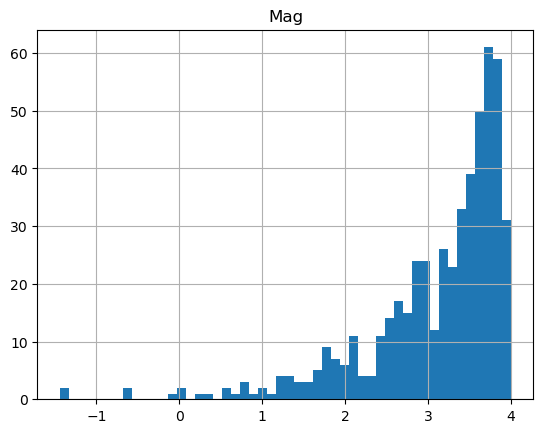

In [11]:
df.hist(column='Mag', bins=50)

## Previous Rand Sky

Text(0, 0.5, 'Frequency')

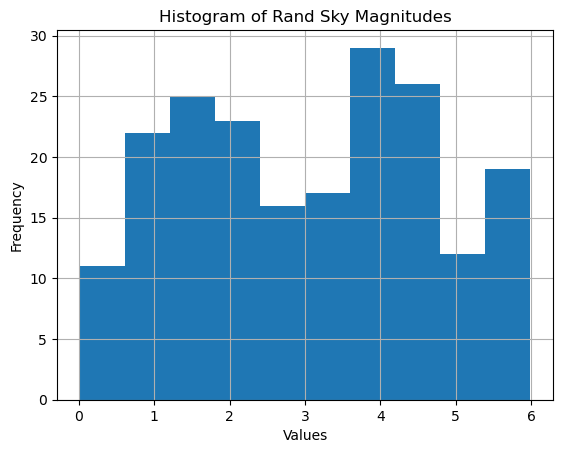

In [12]:
direct = os.getcwd()
name_df = pd.read_csv(direct + '/StarLists/RandSky/ICs/star_data_Jan-29-2024_1400.csv', index_col=None, header=0, names=['Name', 'RA', 'Dec', 'Mag'])
mag_dict = name_df.set_index('Name')['Mag'].to_dict()

# Plot a histogram of a single column in the DataFrame
name_df.hist(column='Mag')

# Set the title and axis labels
plt.title('Histogram of Rand Sky Magnitudes')
plt.xlabel('Values')
plt.ylabel('Frequency')